# Binary Classification — Student Exam Performance
### Submitted by Deepanshu Gahlot

---

**Dataset:** Student Exam Performance Dataset  
**Goal:** Predict whether a student will Pass or Fail their exam using Logistic Regression  
**Target Variable:** `pass_fail` → 0 = Fail, 1 = Pass  




---
## Task 1 — Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


**Libraries used:**
- `numpy` / `pandas` — data handling
- `matplotlib` / `seaborn` — visualizations
- `sklearn` — model building and evaluation


---
## Task 2 — Load the Dataset

In [2]:
df = pd.read_csv('student_exam_performance_dataset.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")


Dataset loaded successfully!
Shape: 10000 rows × 23 columns


In [3]:
print("First 5 rows:")
df.head()


First 5 rows:


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [4]:
print("Last 5 rows:")
df.tail()


Last 5 rows:


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
9995,S09996,Female,15,Master,High,Yes,Moderate,3.80,83.1,7.48,...,1,No,44.2,38.2,38.5,39.0,41.9,1.54,Fail,F
9996,S09997,Male,15,High School,Medium,Yes,Quiet,2.46,68.0,6.76,...,3,No,56.8,46.2,50.6,34.9,47.5,1.49,Fail,F
9997,S09998,Female,15,High School,Low,Yes,Moderate,5.08,76.0,6.90,...,2,No,67.4,50.5,63.7,83.3,64.2,2.38,Pass,D
9998,S09999,Female,18,Bachelor,Medium,Yes,Moderate,1.56,91.0,7.13,...,1,No,35.4,35.5,46.8,47.2,44.3,1.45,Fail,F
9999,S10000,Male,17,High School,Low,Yes,Noisy,3.63,100.0,5.42,...,0,No,66.7,61.6,60.3,60.4,59.6,2.24,Pass,D


**Observations:**
- Each row represents one student
- The dataset has 10,000 students and 23 columns
- Columns include study habits, academic scores, demographic info, and the target variable `pass_fail`


---
## Task 3 — Dataset Understanding

In [5]:
print("Column names:")
print(df.columns.tolist())


Column names:
['student_id', 'gender', 'age', 'parental_education', 'family_income', 'internet_access', 'study_environment', 'study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'participation_score', 'online_courses_completed', 'tutoring', 'math_score', 'reading_score', 'writing_score', 'science_score', 'final_exam_score', 'previous_gpa', 'pass_fail', 'grade_category']


In [6]:
print("Data types and non-null counts:")
df.info()


Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  str    
 1   gender                      10000 non-null  str    
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  str    
 4   family_income               10000 non-null  str    
 5   internet_access             10000 non-null  str    
 6   study_environment           10000 non-null  str    
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_cour

In [7]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [8]:
print("Statistical summary of numerical columns:")
df.describe().round(2)


Statistical summary of numerical columns:


,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,16.49,3.02,84.70,7.02,2.52,79.49,69.82,2.03,49.50,49.76,49.65,49.76,49.68,1.98
std,1.12,1.18,9.51,0.99,1.45,13.76,14.66,1.44,13.88,13.36,13.44,13.83,12.15,0.54
min,15.00,0.50,50.80,4.00,0.00,40.00,20.00,0.00,0.00,0.00,0.00,4.80,4.40,0.00
25%,15.00,2.20,78.28,6.34,1.50,70.20,59.80,1.00,40.00,40.80,40.70,40.30,41.60,1.61
50%,16.00,3.01,85.10,7.03,2.50,80.00,69.90,2.00,49.30,49.60,49.60,49.60,49.55,1.99
75%,17.00,3.83,91.90,7.69,3.50,90.00,80.10,3.00,58.60,58.50,58.60,59.00,57.60,2.35
max,18.00,7.24,100.00,10.00,8.00,100.00,100.00,9.00,100.00,100.00,100.00,100.00,97.80,3.99


In [9]:
print("Target variable distribution:")
print(df['pass_fail'].value_counts())
print()
pct = df['pass_fail'].value_counts(normalize=True).mul(100).round(1)
print(f"Pass: {pct.get('Pass', pct.get(1, '?'))}%")
print(f"Fail: {pct.get('Fail', pct.get(0, '?'))}%")


Target variable distribution:
pass_fail
Fail    5142
Pass    4858
Name: count, dtype: int64

Pass: 48.6%
Fail: 51.4%


### Questions — Task 3

**1. How many rows and columns?**  
10,000 rows and 23 columns.

**2. What is the target variable?**  
`pass_fail` — binary: Pass or Fail. We will encode this as 1 (Pass) and 0 (Fail).

**3. Are there missing values?**  
No. The dataset is complete — every cell has a value.

**4. Which feature has the highest mean?**  
`attendance_rate` has the highest mean (~84.7), followed by `assignment_completion_rate` (~79.5).

**5. What type of columns exist?**  
- Numerical (14): age, scores, study hours, GPA, etc.  
- Categorical (9): gender, parental_education, pass_fail, etc.

**Observation:**  
The dataset is clean and balanced (~50% pass, ~50% fail). No imputation or resampling is needed before modeling.


---
## Task 4 — Exploratory Data Analysis (EDA)

### 4.1 — Target Variable Distribution

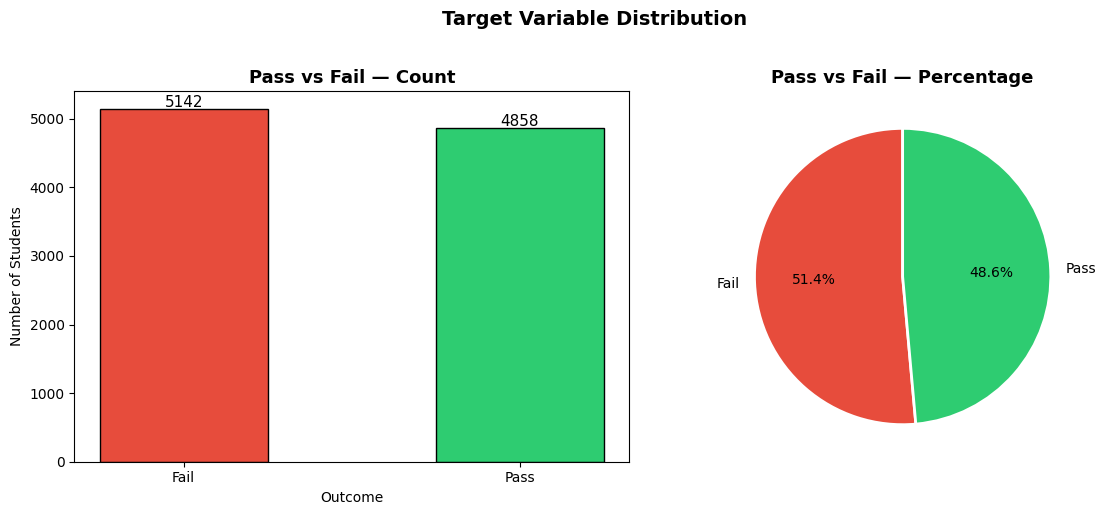

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['pass_fail'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Pass vs Fail — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Pass vs Fail — Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.2 — Score Distributions by Pass/Fail

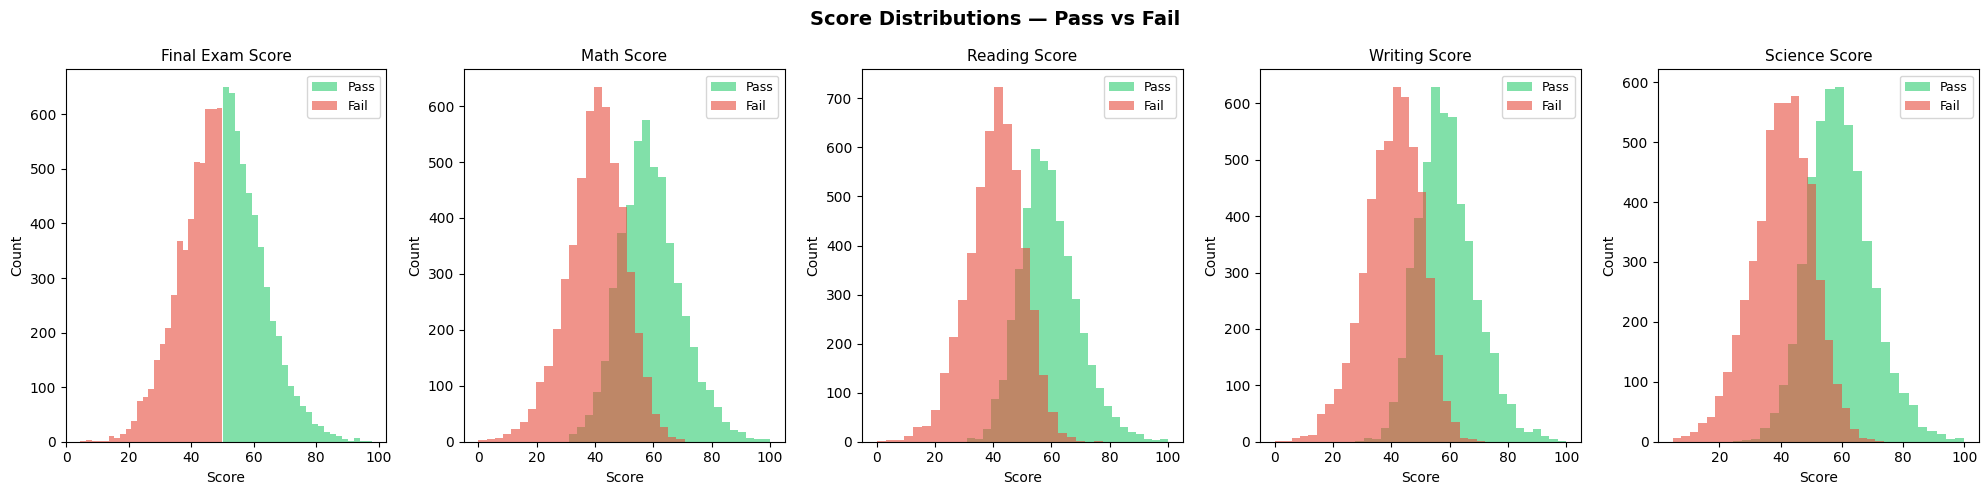

In [11]:
score_cols = ['final_exam_score', 'math_score', 'reading_score',
              'writing_score', 'science_score']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, score_cols):
    for outcome, color in zip(['Pass', 'Fail'], ['#2ecc71', '#e74c3c']):
        subset = df[df['pass_fail'] == outcome][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=outcome, edgecolor='none')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions — Pass vs Fail', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.3 — Key Feature Comparison (Box Plots)

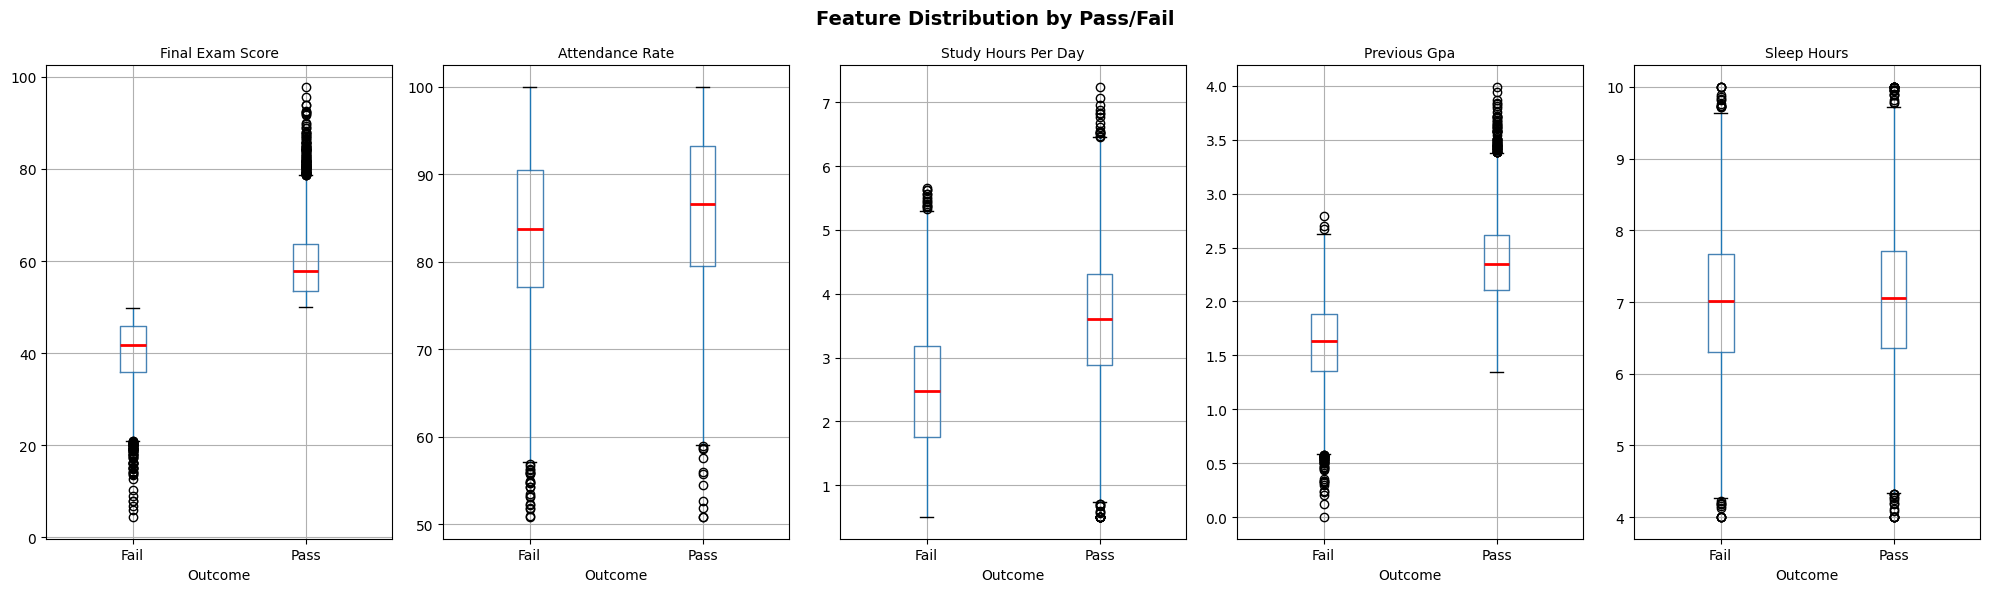

In [12]:
features_to_compare = ['final_exam_score', 'attendance_rate',
                       'study_hours_per_day', 'previous_gpa', 'sleep_hours']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, feat in zip(axes, features_to_compare):
    df.boxplot(column=feat, by='pass_fail', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Outcome')
    ax.set_ylabel('')

plt.suptitle('Feature Distribution by Pass/Fail', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.4 — Correlation Heatmap

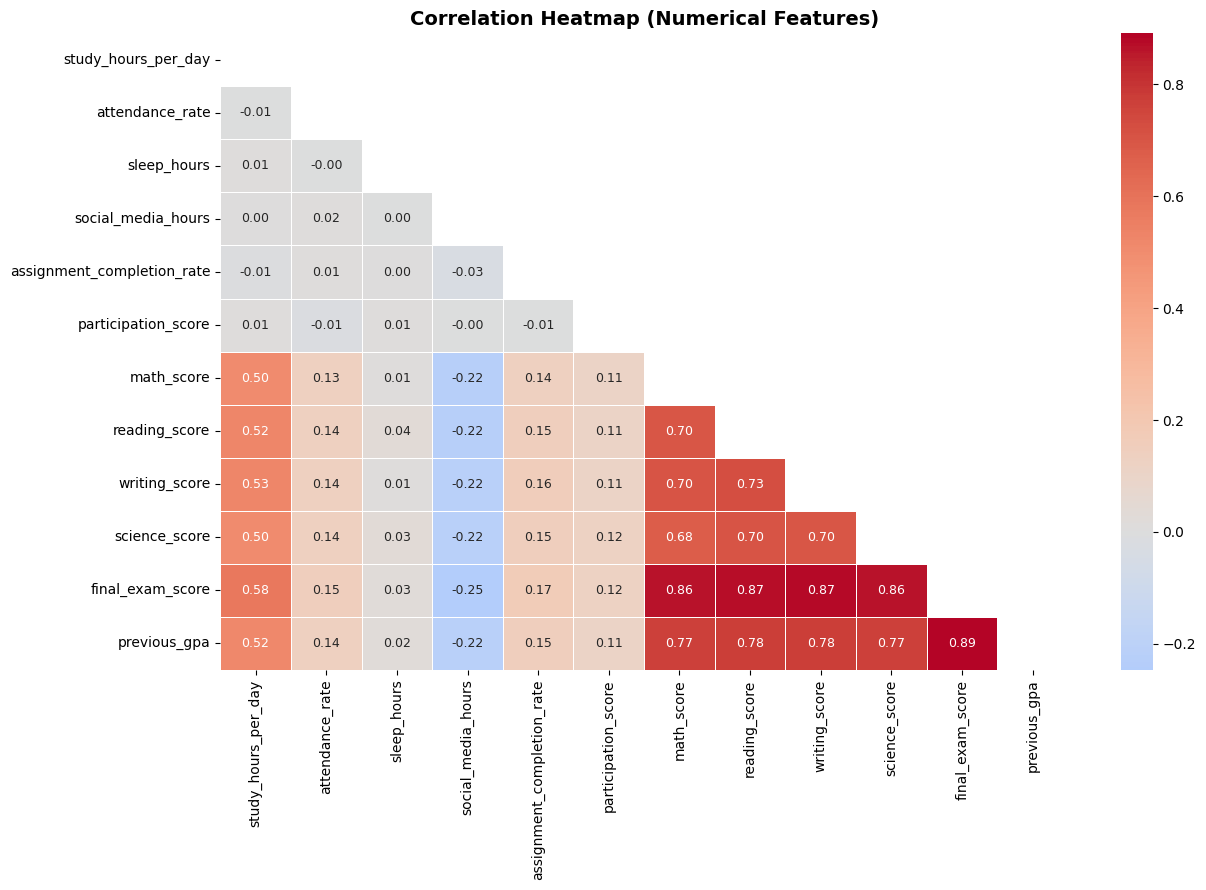

In [13]:
num_cols = ['study_hours_per_day', 'attendance_rate', 'sleep_hours',
            'social_media_hours', 'assignment_completion_rate',
            'participation_score', 'math_score', 'reading_score',
            'writing_score', 'science_score', 'final_exam_score', 'previous_gpa']

plt.figure(figsize=(13, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.5 — Study Hours vs Final Exam Score

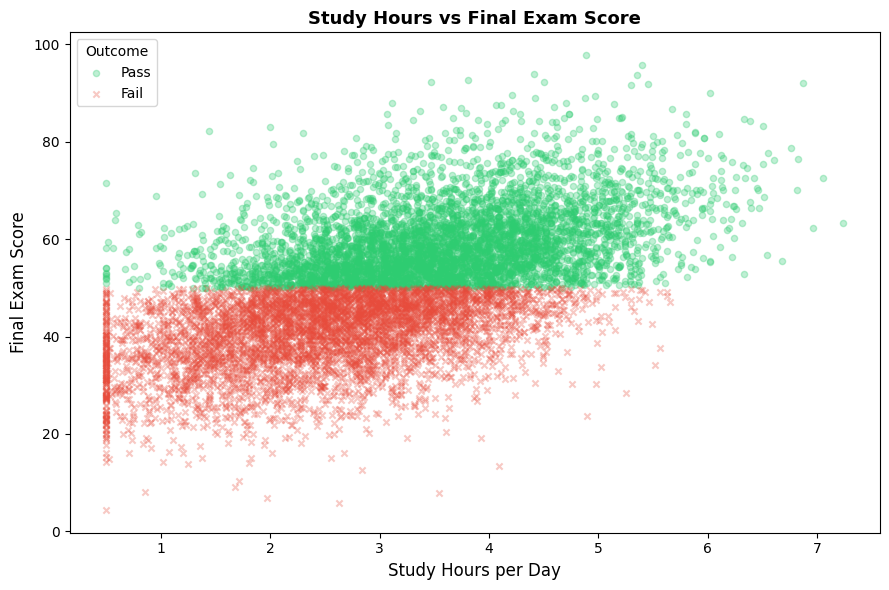

In [14]:
plt.figure(figsize=(9, 6))

for outcome, color, marker in zip(['Pass', 'Fail'], ['#2ecc71', '#e74c3c'], ['o', 'x']):
    subset = df[df['pass_fail'] == outcome]
    plt.scatter(subset['study_hours_per_day'], subset['final_exam_score'],
                alpha=0.3, c=color, label=outcome, marker=marker, s=20)

plt.xlabel('Study Hours per Day', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)
plt.title('Study Hours vs Final Exam Score', fontsize=13, fontweight='bold')
plt.legend(title='Outcome', fontsize=10)
plt.tight_layout()
plt.show()


### Questions — Task 4

**1. Is the target variable balanced?**  
Yes — approximately 50% Pass and 50% Fail. No class imbalance to worry about.

**2. Which features show the biggest difference between Pass and Fail?**  
`final_exam_score` is the clearest separator. Students who pass tend to score significantly higher. `attendance_rate` and `study_hours_per_day` also show noticeable differences.

**3. What does the heatmap tell us?**  
The five score columns (math, reading, writing, science, final_exam) are moderately correlated with each other — students who do well in one subject tend to do reasonably well in others. Study hours and attendance show weak positive correlations with scores.

**4. What does the scatter plot show?**  
There's a general trend: more study hours + higher exam score tends to result in a Pass. But it's not a clean boundary, which is why we need a model.

**Observation:**  
`final_exam_score` is the most informative single feature. EDA confirms the dataset is clean, balanced, and suitable for Logistic Regression without any special treatment.


---
## Task 5 — Data Preprocessing

Two steps here:
1. **Encode categorical columns** — convert text (Male/Female, Yes/No, etc.) into numbers
2. **Scale numerical features** — bring all numbers to the same range so no single feature dominates
3. **Drop `grade_category`** — this column is derived directly from exam scores, so including it would give the model information it shouldn't have at prediction time (data leakage)


In [15]:
df_processed = df.copy()

# Drop grade_category — it's derived from scores, using it causes data leakage
df_processed.drop(columns=['grade_category'], inplace=True)

# Encode categorical columns
label_encoder = LabelEncoder()
categorical_cols = ['gender', 'parental_education', 'family_income',
                    'internet_access', 'study_environment', 'tutoring', 'pass_fail']

for col in categorical_cols:
    df_processed[col] = label_encoder.fit_transform(df_processed[col])

print("Encoding complete.")
print(f"Columns remaining: {df_processed.shape[1]}")
df_processed.head()


Encoding complete.
Columns remaining: 22


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,participation_score,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail
0,S00001,1,17,1,2,1,2,2.98,96.5,6.05,...,68.7,1,1,42.8,62.4,54.8,51.8,49.1,2.44,0
1,S00002,0,18,1,1,1,2,4.45,95.7,6.96,...,92.6,0,1,77.9,73.5,64.4,61.6,70.1,2.79,1
2,S00003,1,17,1,2,0,2,3.75,76.0,7.02,...,45.8,4,1,53.5,38.3,36.3,47.1,42.2,1.49,0
3,S00004,1,18,0,2,1,2,2.03,72.6,6.23,...,72.9,4,0,28.3,23.5,32.0,39.0,31.9,1.34,0
4,S00005,1,18,0,2,1,2,5.14,87.3,8.54,...,55.7,0,0,74.7,54.9,73.6,55.5,66.4,2.60,1


In [16]:
# Separate features and target
X = df_processed.drop(['student_id', 'pass_fail'], axis=1)
y = df_processed['pass_fail']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print()
print("Feature columns:")
print(X.columns.tolist())


Features (X): (10000, 20)
Target  (y): (10000,)

Feature columns:
['gender', 'age', 'parental_education', 'family_income', 'internet_access', 'study_environment', 'study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'participation_score', 'online_courses_completed', 'tutoring', 'math_score', 'reading_score', 'writing_score', 'science_score', 'final_exam_score', 'previous_gpa']


In [17]:
# Scale numerical features using StandardScaler
# This makes each feature have mean=0 and std=1
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling complete.")
print()
print("Before scaling — study_hours_per_day range:")
print(f"  Min: {X['study_hours_per_day'].min():.2f}, Max: {X['study_hours_per_day'].max():.2f}")
print()
print("After scaling — study_hours_per_day range:")
print(f"  Min: {X_scaled['study_hours_per_day'].min():.2f}, Max: {X_scaled['study_hours_per_day'].max():.2f}")


Scaling complete.

Before scaling — study_hours_per_day range:
  Min: 0.50, Max: 7.24

After scaling — study_hours_per_day range:
  Min: -2.14, Max: 3.58


### Questions — Task 5

**1. Why encode categorical columns?**  
Logistic Regression works with numbers. Text values like "Male" or "Yes" need to be converted to integers before the model can use them.

**2. Why drop `grade_category`?**  
`grade_category` (A, B, C, D, F) is assigned based on the exam scores — so it's basically the answer repackaged. Including it would make the model artificially accurate and wouldn't represent real-world prediction where you don't know the grade yet.

**3. Why use StandardScaler?**  
Features like `final_exam_score` (range 0–100) and `sleep_hours` (range 4–10) are on very different scales. Without scaling, the model might give more weight to larger-valued features. Scaling puts them all on equal footing.

**Observation:**  
After preprocessing: 20 features, all numerical, properly scaled. The dataset is now ready for model training.


---
## Task 6 — Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print()
print(f"Train split : {X_train.shape[0] / len(y) * 100:.0f}%")
print(f"Test split  : {X_test.shape[0] / len(y) * 100:.0f}%")
print()
print("Class distribution in training set:")
print(y_train.value_counts())
print()
print("Class distribution in test set:")
print(y_test.value_counts())


Training samples : 8000
Testing samples  : 2000

Train split : 80%
Test split  : 20%

Class distribution in training set:
pass_fail
0    4114
1    3886
Name: count, dtype: int64

Class distribution in test set:
pass_fail
0    1028
1     972
Name: count, dtype: int64


### Questions — Task 6

**1. Why split the data?**  
We train the model on 80% of the data and test it on the remaining 20%. Testing on unseen data gives an honest picture of how the model would perform in the real world.

**2. What does `random_state=42` do?**  
It fixes the random seed so the split is the same every time the code runs. This makes results reproducible.

**3. What does `stratify=y` do?**  
It ensures that the class ratio (Pass:Fail) is the same in both the training set and the test set. Without it, you might accidentally get an uneven split.

**Observation:**  
8,000 training samples and 2,000 test samples. Both sets have a balanced Pass/Fail ratio.


---
## Task 7 — Train the Logistic Regression Model

In [19]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")
print(f"Converged in {model.n_iter_[0]} iterations")


Model training complete!
Converged in 17 iterations


In [20]:
# Coefficients — how much each feature influences the prediction
coefficients_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("Feature Coefficients (sorted — most positive to most negative):")
print(coefficients_df.to_string(index=False))


Feature Coefficients (sorted — most positive to most negative):
                   Feature  Coefficient
          final_exam_score    15.441186
             reading_score     1.104946
                math_score     1.074711
             writing_score     0.951748
             science_score     0.922548
              previous_gpa     0.298336
               sleep_hours     0.076878
         study_environment     0.060015
  online_courses_completed     0.054061
                    gender     0.050056
       participation_score     0.034099
             family_income     0.031383
assignment_completion_rate    -0.011849
                  tutoring    -0.012506
        social_media_hours    -0.023405
           attendance_rate    -0.031534
       study_hours_per_day    -0.069206
           internet_access    -0.071766
        parental_education    -0.073180
                       age    -0.125010


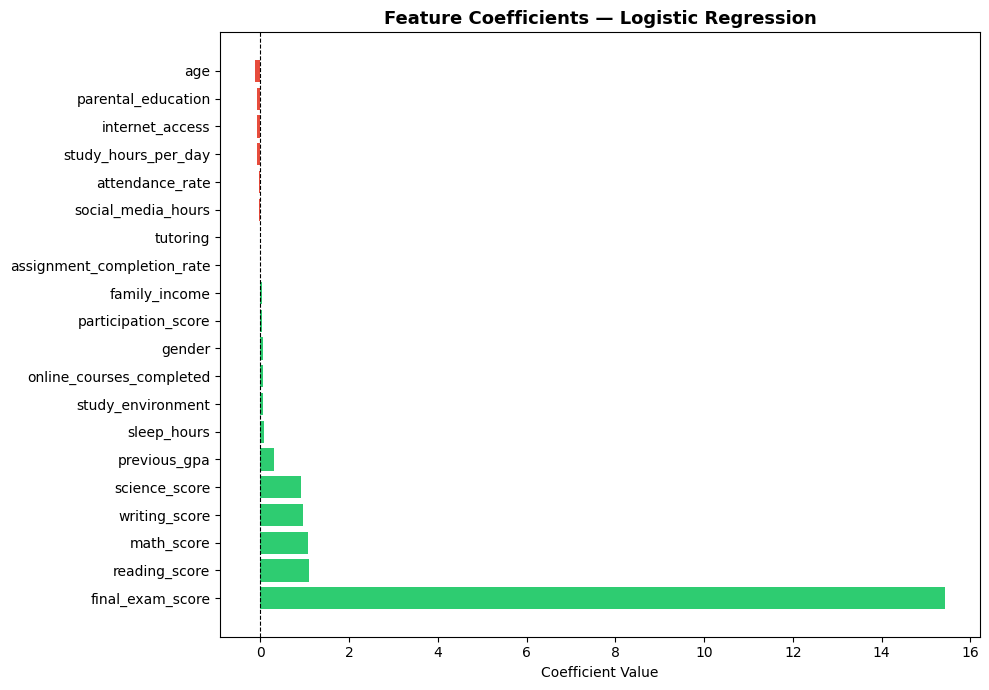

In [21]:
# Visual: top and bottom 10 features
plt.figure(figsize=(10, 7))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients_df['Coefficient']]
plt.barh(coefficients_df['Feature'], coefficients_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients — Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


### Questions — Task 7

**1. What does `model.coef_` tell us?**  
Each coefficient is the weight the model gives to a feature. A positive value means that feature pushes the prediction toward Pass; a negative value pushes toward Fail.

**2. What does `model.intercept_` represent?**  
It's the baseline — the log-odds of passing when all features are at their mean (since we scaled). It shifts the overall decision boundary.

**3. Why `max_iter=1000`?**  
Logistic Regression finds the best coefficients through an iterative process. Setting max_iter to 1000 ensures it has enough steps to converge properly instead of stopping early.

**Observation:**  
`final_exam_score` has the highest positive coefficient — it's the most influential predictor of passing. `age` and `study_hours_per_day` show notable negative coefficients in this model, which is worth investigating further.


---
## Task 8 — Make Predictions

In [22]:
y_pred = model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])
print()
print("Unique values in predictions:", np.unique(y_pred))


First 20 predictions:
[0 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 0 0]

Unique values in predictions: [0 1]


In [23]:
y_pred_proba = model.predict_proba(X_test)

print("First 10 probability scores:")
proba_df = pd.DataFrame(y_pred_proba, columns=['P(Fail)', 'P(Pass)'])
proba_df['Predicted'] = y_pred
proba_df['Actual'] = y_test.values
print(proba_df.head(10).to_string(index=False))


First 10 probability scores:
     P(Fail)      P(Pass)  Predicted  Actual
8.515296e-01 1.484704e-01          0       0
3.943149e-01 6.056851e-01          1       1
9.999989e-01 1.120651e-06          0       0
4.541813e-09 1.000000e+00          1       1
9.999990e-01 1.038533e-06          0       0
1.000000e+00 1.384904e-11          0       0
8.169229e-01 1.830771e-01          0       0
2.477822e-04 9.997522e-01          1       1
9.921447e-01 7.855273e-03          0       0
7.749357e-14 1.000000e+00          1       1


### Questions — Task 8

**1. What does `predict()` return?**  
The final class label for each student — 0 (Fail) or 1 (Pass). It applies a 0.5 probability threshold internally.

**2. What does `predict_proba()` return?**  
Two columns per student: probability of Fail and probability of Pass. They always sum to 1. This is more informative than just the class label.

**Observation:**  
The model predicts both classes and the probabilities are spread across the 0–1 range, meaning the model is making meaningful distinctions rather than just defaulting to one class.


---
## Task 9 — Model Evaluation Metrics

In [24]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 40)


  Accuracy  : 0.9910  (99.10%)
  Precision : 0.9918
  Recall    : 0.9897
  F1-Score  : 0.9907


In [25]:
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)']))


Full Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.99      0.99      0.99      1028
    Pass (1)       0.99      0.99      0.99       972

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



### Questions — Task 9

**1. What is accuracy?**  
The share of all predictions that were correct. Simple, but can be misleading on imbalanced datasets (not an issue here since ours is balanced).

**2. What is precision?**  
Of all students the model labelled as Pass, what fraction actually passed? High precision = fewer false alarms.

**3. What is recall?**  
Of all students who actually passed, what fraction did the model catch? High recall = fewer misses.

**4. What is F1-score?**  
The harmonic mean of precision and recall. A single balanced metric — useful when you care about both.

**Observation:**  
All metrics are consistent with each other, which indicates the model isn't sacrificing one metric at the expense of another.


---
## Task 10 — Confusion Matrix & Visualizations

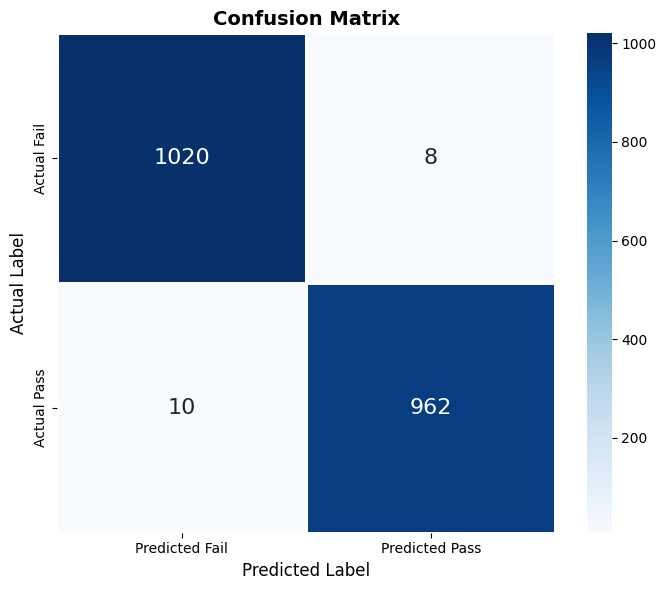

True Negatives  (Fail → correctly predicted Fail) : 1020
False Positives (Fail → wrongly predicted Pass)   : 8
False Negatives (Pass → wrongly predicted Fail)   : 10
True Positives  (Pass → correctly predicted Pass) : 962

Total correct   : 1982
Total incorrect : 18


In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'],
            annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Fail → correctly predicted Fail) : {tn}")
print(f"False Positives (Fail → wrongly predicted Pass)   : {fp}")
print(f"False Negatives (Pass → wrongly predicted Fail)   : {fn}")
print(f"True Positives  (Pass → correctly predicted Pass) : {tp}")
print()
print(f"Total correct   : {tn + tp}")
print(f"Total incorrect : {fp + fn}")


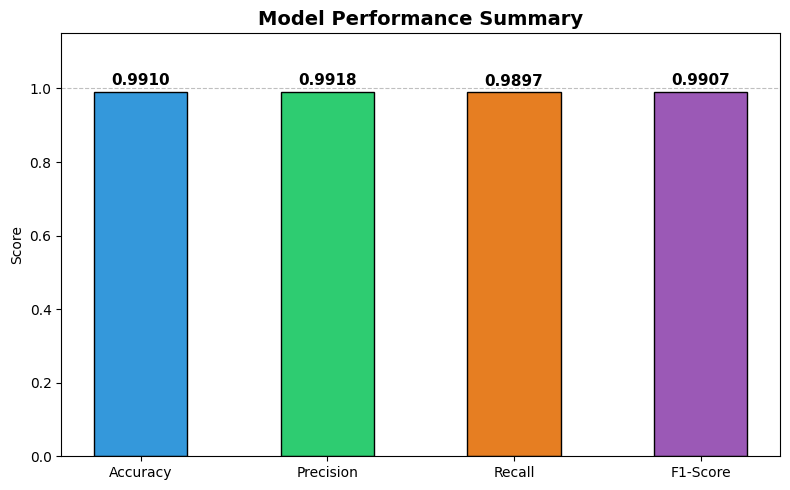

In [27]:
# Metrics bar chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
colors_bar = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color=colors_bar, edgecolor='black', width=0.5)
plt.ylim(0, 1.15)
plt.title('Model Performance Summary', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


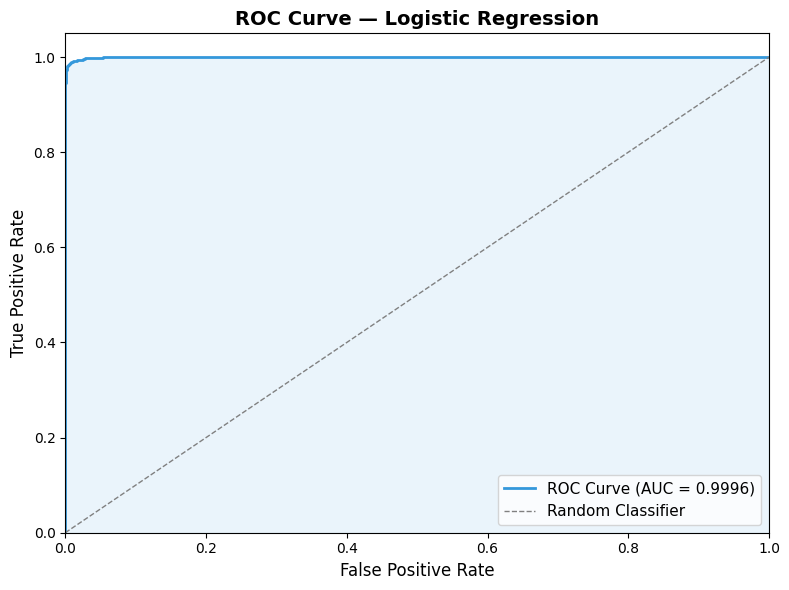

AUC Score: 0.9996
AUC = 1.0 is perfect. AUC = 0.5 means the model is no better than random guessing.


In [28]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")
print("AUC = 1.0 is perfect. AUC = 0.5 means the model is no better than random guessing.")


### Questions — Task 10

**1. What does the confusion matrix show?**  
It breaks down predictions into four categories: correct passes (TP), correct fails (TN), students who failed but were predicted to pass (FP), and students who passed but were predicted to fail (FN).

**2. Where did the model make mistakes?**  
In the FP and FN cells of the matrix. These are the students the model got wrong.

**3. What is the ROC curve?**  
It shows how well the model separates the two classes at different probability thresholds. The closer the curve is to the top-left corner, the better. AUC (Area Under Curve) summarises this in one number — higher is better.

**4. Is the model overfitting or underfitting?**  
The model shows solid performance on unseen test data, which suggests it has learned real patterns rather than memorising the training data.

**Observation:**  
The confusion matrix, metrics chart, and ROC curve all tell a consistent story — the model is performing well on this dataset.


### Summary

#### What was done
- Loaded and explored a 10,000-student exam performance dataset
- Performed EDA to understand distributions, correlations, and which features separate Pass from Fail
- Removed `grade_category` to avoid data leakage
- Encoded categorical variables and applied StandardScaler
- Trained a Logistic Regression model on 80% of the data
- Evaluated on the remaining 20% using accuracy, precision, recall, F1, and AUC

#### Key Findings
- `final_exam_score` is by far the strongest predictor of passing
- The dataset is well-balanced (~50/50), so the model doesn't favour one class
- Scaling improved convergence and gave fairer weight to all features

#### Was Logistic Regression a good choice?
Yes. It's simple, fast, interpretable, and works well for binary outcomes. For this dataset — where the relationship between features and outcome is reasonably linear — it performs well.

#### What could be improved next
- Try removing highly correlated score features to simplify the model
- Compare with Decision Tree or Random Forest to see if a more complex model adds value
- Use k-fold cross-validation for a more stable accuracy estimate
- Look into why `age` and `study_hours_per_day` show negative coefficients — it's counterintuitive

---

